### Predeccion de Aceptación de Oferta Push

###  Algoritmo LightGBM

### Descripcion del Problema 

### La oferta Push es una promoción personalizada que el banco envia directamente al cliente sin que el cliente la haya solicitado previamente 

Generalemte son: 

Prestamos preaprobados

Envios por la movil o llamadas o SMS 


## Objetivo del modelo: Utilizar datos de campañas anteriores, para constriuir un modelo que clasifique si un cliente acepta o no una oferta push de un prestamo 

## Variable objetivo  sera:

1: el cliente acepta el prestamo

0 : el cliente rechaza el prestamo

## LightGBM es un algoritmo de aprendizaje supervisado 

El aprendizaje supervisado implica que el modelo aprende a apartir de ejemplos etiquetados

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns 

In [11]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [12]:
#!pip install lightgbm

### Exploración inicial de los datos 

In [14]:
# # Dimensiones del data set 
df.shape

(45211, 17)

In [15]:
#!python --version

In [16]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [17]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

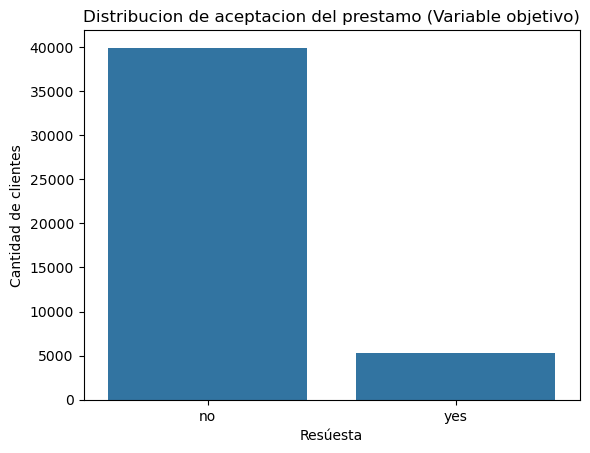

In [18]:
# Distribucion de la variable objetivo
sns.countplot(x="y", data=df)
plt.title("Distribucion de aceptacion del prestamo (Variable objetivo)")
plt.xlabel("Resúesta")
plt.ylabel("Cantidad de clientes")
plt.show()

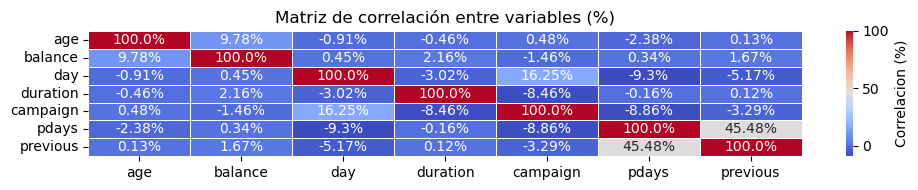

In [19]:
corr_matrix = df.corr(numeric_only=True) * 100 

#Formatear los valores como string para concatenar el simboiolo % 
labels = corr_matrix.round(2).astype(str) + "%"

#Dibujar el heatmap
plt.figure(figsize=(10,2))
sns.heatmap(corr_matrix,
           annot= labels, # Mostrar los valores como texto 
           fmt="",
           cmap="coolwarm",
           linewidths=0.5,
           cbar_kws={"label": "Correlacion (%)"}
           )
plt.title("Matriz de correlación entre variables (%)")
plt.tight_layout()
plt.show()

In [20]:
# Crear columna binaria
df["acepta_prestamo"]= df["y"].map({"yes":1,"no":0})


In [21]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,acepta_prestamo
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


## Preprocesamiento de datos 

In [23]:
# Eliminar la columna original Y
df.drop(columns=["y"], inplace=True)

In [24]:
# Obtener todas las columnas que son categoricas
cat_cols = df.select_dtypes(include=["object"]).columns

# Crear un diccionario para almacenar los codificadores LabelEncoder
label_encoders = {}

#recorrer cada columna categorica para codificar sus valores
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,acepta_prestamo
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0
5,35,4,1,2,0,231,1,0,2,5,8,139,1,-1,0,3,0
6,28,4,2,2,0,447,1,1,2,5,8,217,1,-1,0,3,0
7,42,2,0,2,1,2,1,0,2,5,8,380,1,-1,0,3,0
8,58,5,1,0,0,121,1,0,2,5,8,50,1,-1,0,3,0
9,43,9,2,1,0,593,1,0,2,5,8,55,1,-1,0,3,0


## Separar los datos en entrenamiento y prueba

In [26]:
#Columnas predictoras
x = df.drop("acepta_prestamo", axis=1) 

#Columna de clasificacion 
y = df["acepta_prestamo"]


In [27]:
# Dividir la informacion en entrenamiento y prueba
x_train, x_val, y_train, y_val = train_test_split(x,y, test_size=0.2, random_state=42)


# Entranamiento del modelo 

In [29]:
# Activamos el balanceo automatico de clases dentro del modelo para corregir
# desbalanceo en el dataset de entrada
modelo = lgb.LGBMClassifier(class_weight="balanced")
modelo.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 4198, number of negative: 31970
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 989
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced')

## Evaluacion del modelo 

In [31]:
y_pred = modelo.predict(x_val)
print("Accuracy", accuracy_score(y_val,y_pred))


Accuracy 0.8551365697224372


## Matriz de confusión

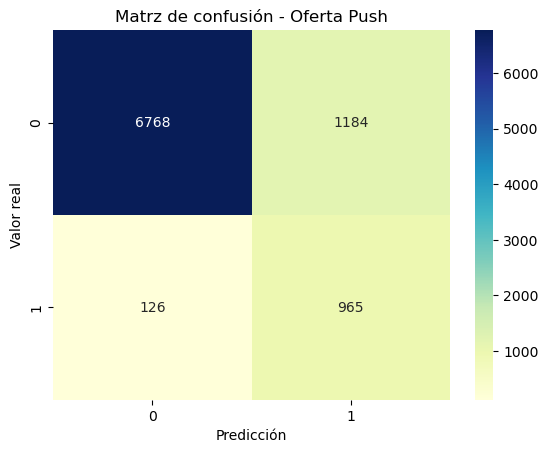

In [33]:
matriz = confusion_matrix(y_val,y_pred)
sns.heatmap(matriz, annot=True, fmt="d",cmap="YlGnBu")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matrz de confusión - Oferta Push")
plt.show()

In [34]:
df["acepta_prestamo"].value_counts() 

acepta_prestamo
0    39922
1     5289
Name: count, dtype: int64

## Suponer que se recibe dos nuevos clientes 

In [60]:
cliente_rechazo = pd.DataFrame({
    "age": [52],
    "job": ["blue-collar"],
    "marital": ["married"],
    "education":["primary"],
    "default":["yes"],
    "balance":[100], # saldo actual en su cuenta
    "housing":["yes"], # tiene hipoteca
    "loan": ["yes"], # tiene otro prestamo
    "contact": ["unknown"], # medio desconocido
    "day":[3],
    "month": ["nov"],
    "duration":[20], #Tiempo de llamada
    "campaign": [4],
    "pdays": [999], # periodo de dias desde que se contacto al cliente
    "previous": [0], # Sin seguimiento
    "poutcome": ["failure"] # Rechazo la ultima oferta push
})

nuevo_cliente = pd.DataFrame({
    "age": [35],
    "job": ["blue-collar"],
    "marital": ["married"],
    "education":["primary"],
    "default":["yes"],
    "balance":[1500], # saldo actual en su cuenta
    "housing":["yes"], # tiene hipoteca
    "loan": ["yes"], # tiene otro prestamo
    "contact": ["unknown"], # medio desconocido
    "day":[3],
    "month": ["nov"],
    "duration":[600], #Tiempo de llamada
    "campaign": [4],
    "pdays": [300], # periodo de dias desde que se contacto al cliente
    "previous": [0], # Sin seguimiento
    "poutcome": ["success"] # Rechazo la ultima oferta push
})


nuevos_clientes = pd.concat([cliente_rechazo,nuevo_cliente], ignore_index=True)

In [62]:
nuevos_clientes

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,52,blue-collar,married,primary,yes,100,yes,yes,unknown,3,nov,20,4,999,0,failure
1,35,blue-collar,married,primary,yes,1500,yes,yes,unknown,3,nov,600,4,300,0,success


In [66]:
# Aplicar los mismos encoders que se usaron en el entrenamiento
for col in nuevos_clientes.columns:
    if col in label_encoders:
        nuevos_clientes[col]= label_encoders[col].transform(nuevos_clientes[col])

In [68]:
nuevos_clientes

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,52,1,1,0,1,100,1,1,2,3,9,20,4,999,0,0
1,35,1,1,0,1,1500,1,1,2,3,9,600,4,300,0,2


In [70]:
prediccion = modelo.predict(nuevos_clientes)

In [72]:
#Probabilidad de aceptar
probabilidad_aceptar = modelo.predict_proba(nuevos_clientes)[:,1]

#Probabilidad de rechazo
probabilidad_rechazo = modelo.predict_proba(nuevos_clientes)[:,0]

#Confianza del modelo 
confianza_modelo = np.max(modelo.predict_proba(nuevos_clientes), axis=1)


#Crear dataframe dde resultados
resultado = nuevos_clientes.copy()
resultado["Probabilidad de aceptar el prestamo"] =probabilidad_aceptar
resultado["Probabilidad de rechazar el prestamo"] =probabilidad_rechazo
resultado["clase_predicha"] = prediccion
resultado["confianza del modelo"] = confianza_modelo
resultado["prediccion final"] = np.where(prediccion==1,"Si acepta", "No acepta")



In [74]:
resultado

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,Probabilidad de aceptar el prestamo,Probabilidad de rechazar el prestamo,clase_predicha,confianza del modelo,prediccion final
0,52,1,1,0,1,100,1,1,2,3,...,20,4,999,0,0,0.007491,0.992509,0,0.992509,No acepta
1,35,1,1,0,1,1500,1,1,2,3,...,600,4,300,0,2,0.657462,0.342538,1,0.657462,Si acepta
